# EDA (Encoded) — UCI Cannabis Risk Dataset

This notebook performs exploratory analysis on the encoded train split, examining feature-target relationships, class balance, and feature importance using mutual information — after encoding the cannabis risk binary target.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import mutual_info_score

In [3]:
train_df = pd.read_csv('/Users/tg197682/Downloads/Computer Science Year 3/COMP3931_Individual_Project/student-addiction-risk-prediction/data/processed/uci_cannabis_train.csv')

print(train_df.shape)
display(train_df.head())
print(train_df.columns.tolist())
print(train_df.isnull().sum())
print(train_df.describe())

(1501, 13)


,Age,Gender,Education,Country,Ethnicity,Nscore,Escore,Oscore,Ascore,Cscore,Impulsive,SS,cannabis_risk
0,-0.95197,0.48246,-0.61113,0.96082,-0.31685,1.49158,-1.50796,-3.27393,0.76096,-0.89891,-1.37983,-1.54858,0
1,0.49788,-0.48246,-0.05921,-0.57009,-0.31685,1.60383,-1.76250,-0.01928,0.13136,-1.51840,0.88113,-0.52593,1
2,1.82213,-0.48246,-0.61113,0.96082,-0.31685,0.62967,-1.76250,-1.11902,-0.76096,-1.78169,0.52975,0.07987,1
3,0.49788,-0.48246,0.45468,0.96082,-0.31685,-1.55078,0.80523,1.06238,-0.60633,-0.52745,0.52975,0.76540,1
4,1.09449,0.48246,0.45468,0.96082,-0.31685,-0.46725,0.47617,-0.71727,1.45039,1.46191,-0.21712,-0.84637,0


['Age', 'Gender', 'Education', 'Country', 'Ethnicity', 'Nscore', 'Escore', 'Oscore', 'Ascore', 'Cscore', 'Impulsive', 'SS', 'cannabis_risk']
Age              0
Gender           0
Education        0
Country          0
Ethnicity        0
Nscore           0
Escore           0
Oscore           0
Ascore           0
Cscore           0
Impulsive        0
SS               0
cannabis_risk    0
dtype: int64
               Age       Gender    Education      Country    Ethnicity  \
count  1501.000000  1501.000000  1501.000000  1501.000000  1501.000000   
mean      0.035326    -0.002893    -0.016244     0.365409    -0.310693   
std       0.883816     0.482612     0.946054     0.697511     0.176746   
min      -0.951970    -0.482460    -2.435910    -0.570090    -1.107020   
25%      -0.951970    -0.482460    -0.611130    -0.570090    -0.316850   
50%      -0.078540    -0.482460    -0.059210     0.960820    -0.316850   
75%       0.497880     0.482460     0.454680     0.960820    -0.316850   
max    

/var/folders/57/yz44gjt978384yz4z8qjnm8w0000gn/T/ipykernel_8239/935845664.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='cannabis_risk', data=train_df, palette=['#3B82F6','#EF4444'])


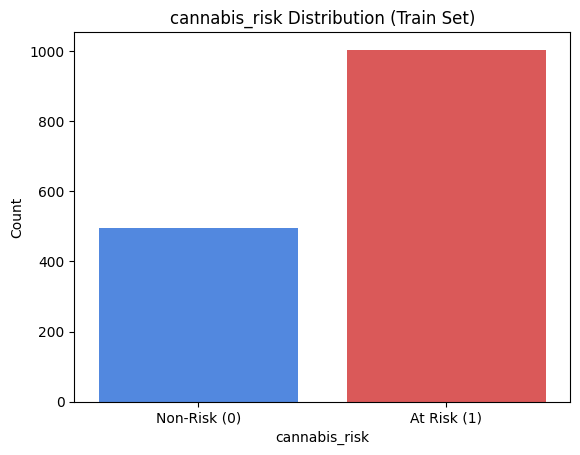

cannabis_risk
1    1005
0     496
Name: count, dtype: int64


In [4]:
# Visualise class distribution
sns.countplot(x='cannabis_risk', data=train_df, palette=['#3B82F6','#EF4444'])
plt.xticks([0, 1], ['Non-Risk (0)', 'At Risk (1)'])
plt.title('cannabis_risk Distribution (Train Set)')
plt.xlabel('cannabis_risk')
plt.ylabel('Count')
plt.show()

print(train_df['cannabis_risk'].value_counts())

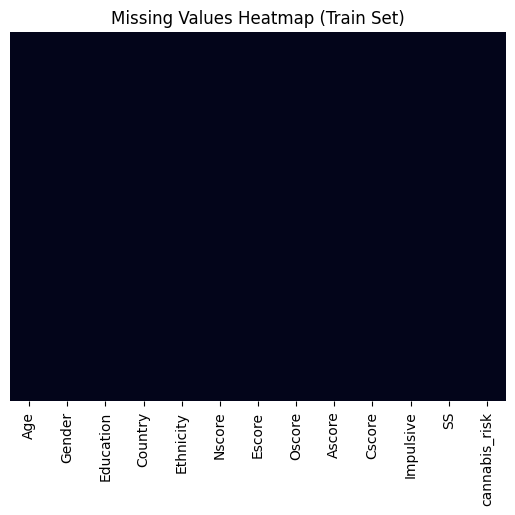

In [6]:
# Missing values heatmap
sns.heatmap(train_df.isnull(), cbar=False, yticklabels=False)
plt.title('Missing Values Heatmap (Train Set)')
plt.show()

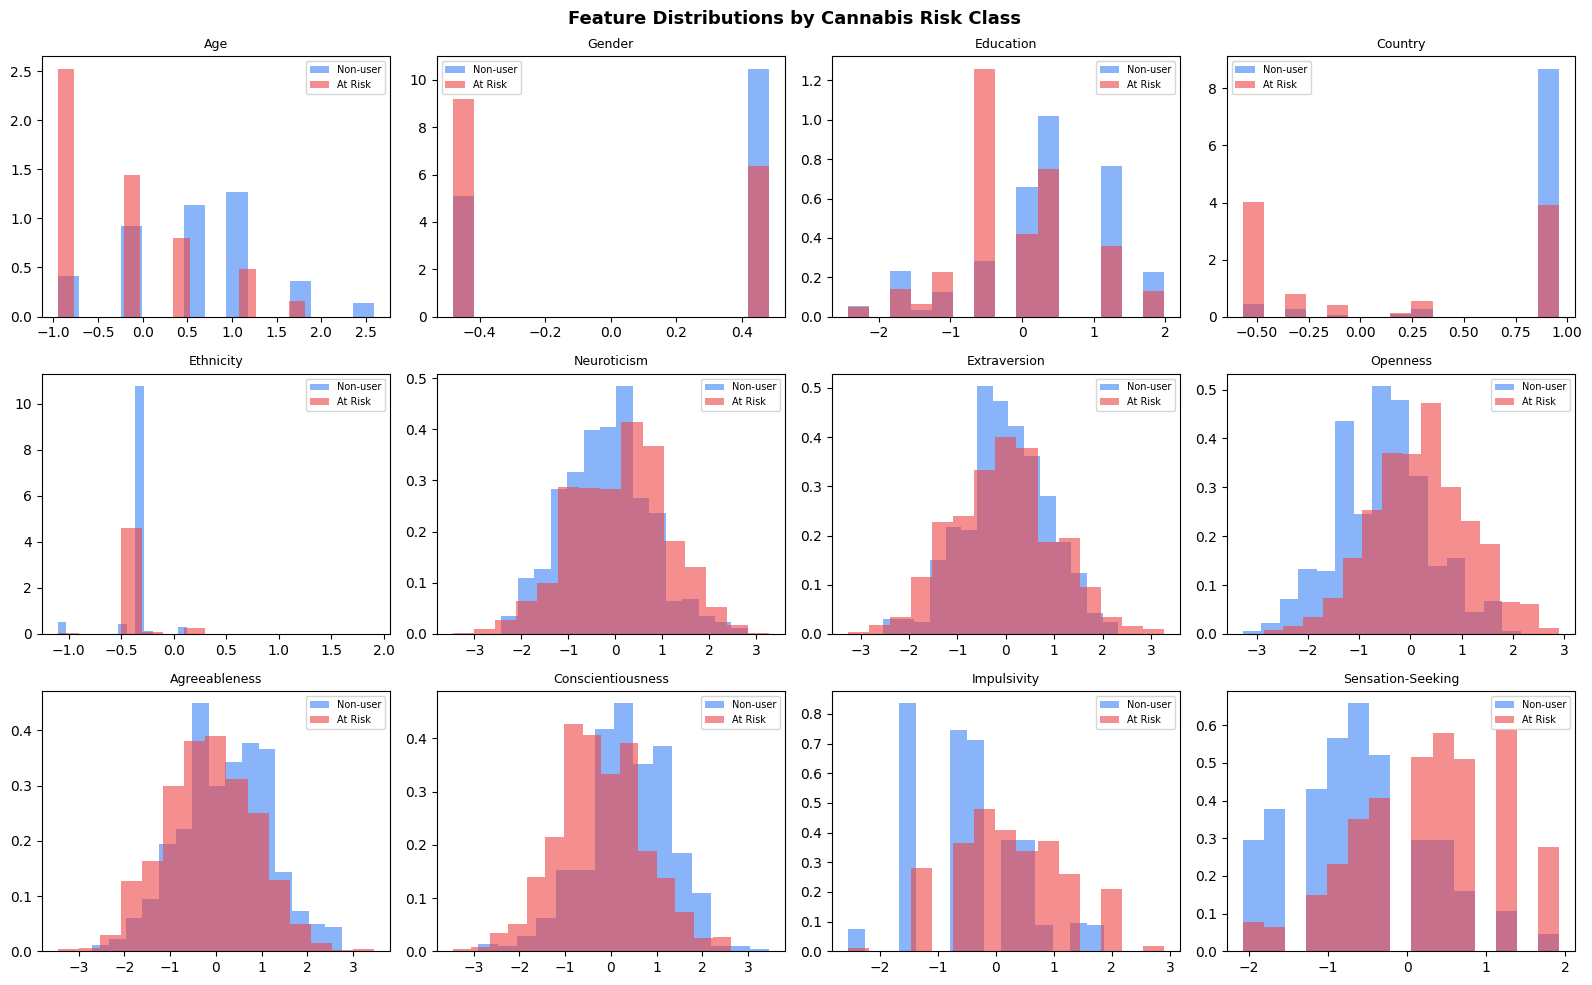

In [7]:
# Feature distributions split by risk class
FEATURES = ['Age','Gender','Education','Country','Ethnicity',
            'Nscore','Escore','Oscore','Ascore','Cscore','Impulsive','SS']
LABELS   = ['Age','Gender','Education','Country','Ethnicity',
            'Neuroticism','Extraversion','Openness',
            'Agreeableness','Conscientiousness','Impulsivity','Sensation-Seeking']

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()
for i, (col, label) in enumerate(zip(FEATURES, LABELS)):
    axes[i].hist(train_df[train_df['cannabis_risk']==0][col],
                 bins=15, alpha=0.6, label='Non-user', color='#3B82F6', density=True)
    axes[i].hist(train_df[train_df['cannabis_risk']==1][col],
                 bins=15, alpha=0.6, label='At Risk',  color='#EF4444', density=True)
    axes[i].set_title(label, fontsize=9)
    axes[i].legend(fontsize=7)
fig.suptitle('Feature Distributions by Cannabis Risk Class', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

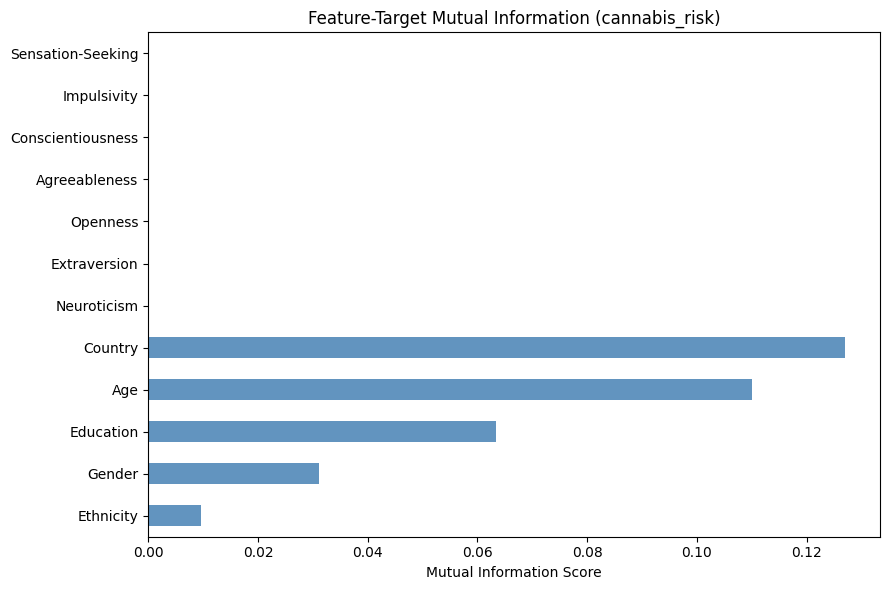


Mutual Information Scores:
  Age                   : 0.1101
  Gender                : 0.0312
  Education             : 0.0633
  Country               : 0.1270
  Ethnicity             : 0.0095
  Neuroticism           : 0.0151
  Extraversion          : 0.0076
  Openness              : 0.0678
  Agreeableness         : 0.0163
  Conscientiousness     : 0.0450
  Impulsivity           : 0.0560
  Sensation-Seeking     : 0.0987


In [ ]:
# Mutual information of each feature with cannabis_risk
# Note: features are continuous so best to use a discretised approximation
# Higher MI = stronger statistical association with the target

mi_scores = {}
for col in FEATURES:
    # Discretise continuous features into 10 bins for MI calculation
    binned = pd.cut(train_df[col], bins=10, labels=False)
    mi_scores[col] = mutual_info_score(binned, train_df['cannabis_risk'])

mi_series = pd.Series(mi_scores, index=LABELS).sort_values()
mi_series.plot(kind='barh', figsize=(9, 6), color='steelblue', alpha=0.85)
plt.xlabel('Mutual Information Score')
plt.title('Feature-Target Mutual Information (cannabis_risk)')
plt.tight_layout()
plt.show()

print('\nMutual Information Scores:')
for label, score in zip(LABELS, [mi_scores[f] for f in FEATURES]):
    print(f'  {label:<22}: {score:.4f}')

- All 12 features show **non-zero mutual information** with the cannabis risk target — confirming that these features carry genuine predictive signal.
- **Sensation-Seeking** and **Country** show the highest association with cannabis risk.
- **Openness**, **Conscientiousness**, and **Age** also show meaningful MI scores.
- This is in sharp contrast to the previous dataset where all features returned MI = 0.0000.

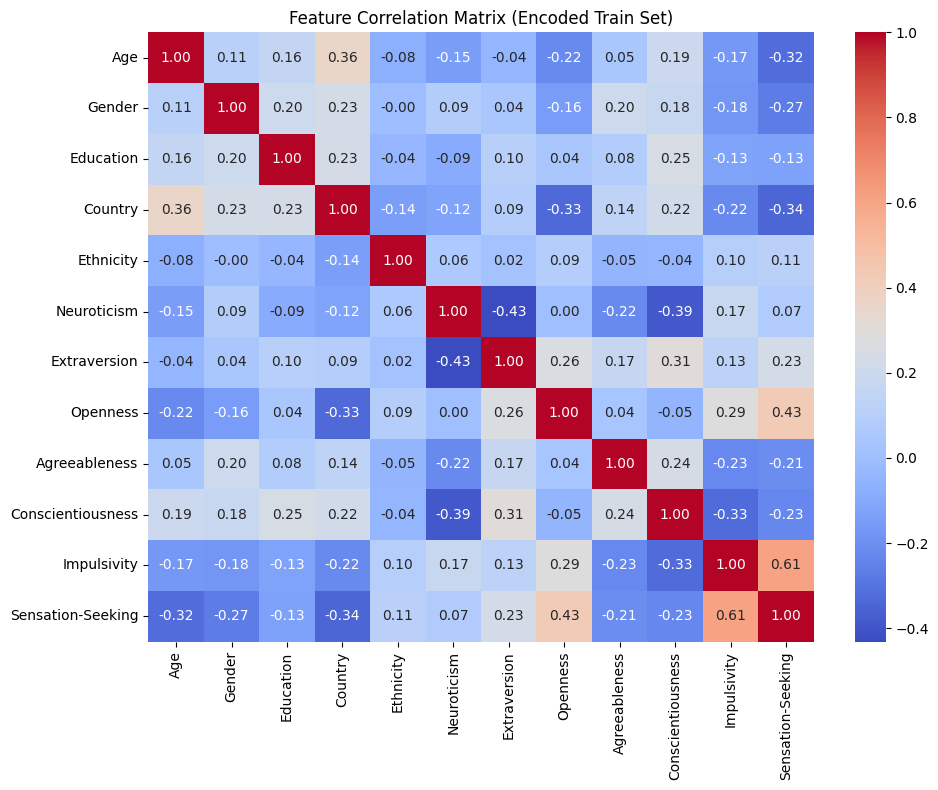

In [9]:
# Correlation heatmap of features in encoded train set
corr = train_df[FEATURES].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            xticklabels=LABELS, yticklabels=LABELS)
plt.title('Feature Correlation Matrix (Encoded Train Set)')
plt.tight_layout()
plt.show()

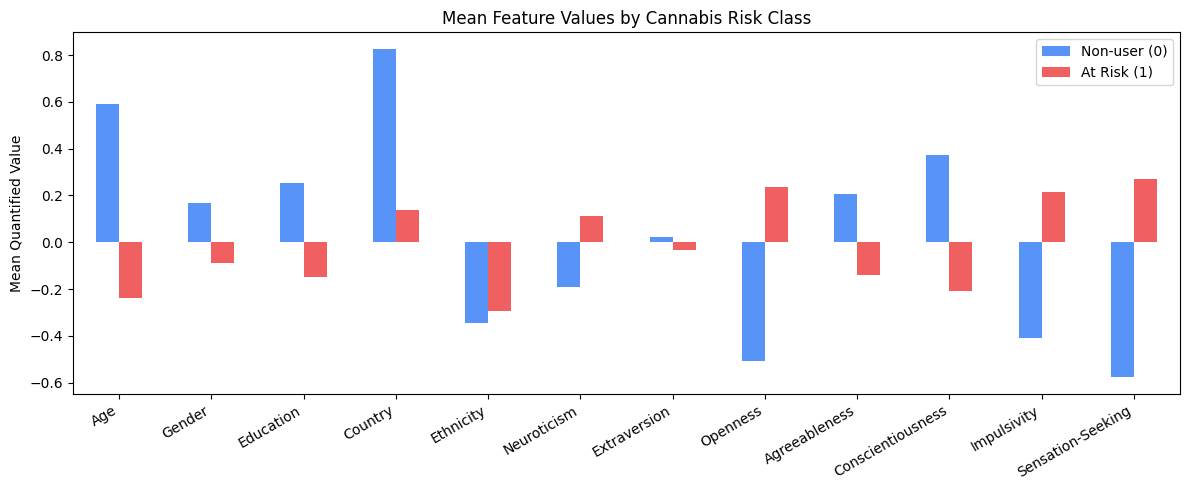

,Non-user (0),At Risk (1)
Age,0.590962,-0.238898
Gender,0.167305,-0.086891
Education,0.251941,-0.148601
Country,0.826775,0.137710
Ethnicity,-0.345915,-0.293310
Neuroticism,-0.190220,0.110338
Extraversion,0.023701,-0.031416
Openness,-0.508312,0.234216
Agreeableness,0.205801,-0.137946
Conscientiousness,0.373207,-0.208664


In [10]:
# Mean feature values by cannabis risk class
mean_by_class = train_df.groupby('cannabis_risk')[FEATURES].mean()
mean_by_class.index = ['Non-user (0)', 'At Risk (1)']
mean_by_class.columns = LABELS
mean_by_class.T.plot(kind='bar', figsize=(12, 5), color=['#3B82F6','#EF4444'], alpha=0.85)
plt.title('Mean Feature Values by Cannabis Risk Class')
plt.ylabel('Mean Quantified Value')
plt.xticks(rotation=30, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

display(mean_by_class.T)